# Complete exploratory data analysis notebook

Author: Maria Jorda

Date: 22 Feb 2026

In this notebook we carry out a comprehensive exploratory data analysis for a dataset containing data of an E-commerce

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Data download

In [2]:
df_orders = pd.read_csv('/Users/mariajordamunoz/Documents/formación/data science - zrive/semana 2/zrive-grocery-box-builder/feature_frame.csv')
print(df_orders.shape)
df_orders.head()

(2880549, 27)


,variant_id,product_type,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
0,33826472919172,ricepastapulses,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
1,33826472919172,ricepastapulses,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
2,33826472919172,ricepastapulses,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05 00:00:00,4,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
3,33826472919172,ricepastapulses,2808393957508,3291363377284,2020-10-06 08:57:59,2020-10-06 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
4,33826472919172,ricepastapulses,2808429314180,3537167515780,2020-10-06 10:37:05,2020-10-06 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618


## Sanity checks


### 1. Data types

In [3]:
df_orders.dtypes

variant_id                            int64
product_type                         object
order_id                              int64
user_id                               int64
created_at                           object
order_date                           object
user_order_seq                        int64
outcome                             float64
ordered_before                      float64
abandoned_before                    float64
active_snoozed                      float64
set_as_regular                      float64
normalised_price                    float64
discount_pct                        float64
vendor                               object
global_popularity                   float64
count_adults                        float64
count_children                      float64
count_babies                        float64
count_pets                          float64
people_ex_baby                      float64
days_since_purchase_variant_id      float64
avg_days_to_buy_variant_id      

In [4]:
df_orders.describe()

,variant_id,order_id,user_id,user_order_seq,outcome,ordered_before,abandoned_before,active_snoozed,set_as_regular,normalised_price,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
count,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,...,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06
mean,3.401250e+13,2.978388e+12,3.750025e+12,3.289342e+00,1.153669e-02,2.113868e-02,6.092589e-04,2.290188e-03,3.629864e-03,1.272808e-01,...,5.492182e-02,3.538562e-03,5.134091e-02,2.072549e+00,3.312961e+01,3.523734e+01,2.645304e+01,3.143513e+01,3.088810e+01,2.594969e+01
std,2.786246e+11,2.446292e+11,1.775710e+11,2.140176e+00,1.067876e-01,1.438466e-01,2.467565e-02,4.780109e-02,6.013891e-02,1.268378e-01,...,3.276586e-01,5.938048e-02,3.013646e-01,3.943659e-01,3.707162e+00,1.057766e+01,7.168323e+00,1.227511e+01,4.330262e+00,3.278860e+00
min,3.361529e+13,2.807986e+12,3.046041e+12,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.599349e-02,...,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.414214e+00,0.000000e+00,7.000000e+00,2.828427e+00
25%,3.380354e+13,2.875152e+12,3.745901e+12,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.394416e-02,...,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,3.300000e+01,3.000000e+01,2.319372e+01,3.000000e+01,2.800000e+01,2.427618e+01
50%,3.397325e+13,2.902856e+12,3.812775e+12,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.105178e-02,...,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,3.300000e+01,3.400000e+01,2.769305e+01,3.000000e+01,3.100000e+01,2.608188e+01
75%,3.428495e+13,2.922034e+12,3.874925e+12,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.352670e-01,...,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,3.300000e+01,4.000000e+01,3.059484e+01,3.000000e+01,3.400000e+01,2.796118e+01
max,3.454300e+13,3.643302e+12,5.029635e+12,2.100000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,3.000000e+00,1.000000e+00,6.000000e+00,5.000000e+00,1.480000e+02,8.400000e+01,5.868986e+01,1.480000e+02,3.950000e+01,3.564191e+01


We should change the datatype of 'created_at' and 'order_date' because they're datetimes. Additionaly, I think it's better for boolean values to be intergers, not floats, so I'll also change the data types of boolean values. To know which variables are boolean we check the max and min of the variables (they should be 1 and 0 respectively) or the .value_counts() of the variables. I'll also change other float variables like 'count_adults' to interger.

In [5]:
df_orders['created_at'] = df_orders['created_at'].astype('datetime64[ns]')
df_orders['order_date'] = df_orders['order_date'].astype('datetime64[ns]')

In [6]:
print(df_orders['avg_days_to_buy_variant_id'].value_counts())

avg_days_to_buy_variant_id
34.0    274971
30.0    150497
32.0    128927
38.0    122523
31.0    109710
         ...  
12.5      1460
10.5      1431
1.0        946
4.5        817
9.5        594
Name: count, Length: 122, dtype: int64


In [7]:
boolean_columns = df_orders[['outcome', 'ordered_before', 'abandoned_before', 'active_snoozed', 'set_as_regular']]
interger_columns = df_orders[['days_since_purchase_variant_id', 'days_since_purchase_product_type', 'count_adults', 'count_children', 'count_babies', 'count_pets', 'people_ex_baby']]

for column in boolean_columns:
    df_orders[column] = df_orders[column].astype('int64')

for column in interger_columns:
    df_orders[column] = df_orders[column].astype('int64')

In [8]:
df_orders.head()

,variant_id,product_type,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
0,33826472919172,ricepastapulses,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05,3,0,0,0,...,0,0,0,2,33,42.0,31.134053,30,30.0,24.27618
1,33826472919172,ricepastapulses,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05,2,0,0,0,...,0,0,0,2,33,42.0,31.134053,30,30.0,24.27618
2,33826472919172,ricepastapulses,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05,4,0,0,0,...,0,0,0,2,33,42.0,31.134053,30,30.0,24.27618
3,33826472919172,ricepastapulses,2808393957508,3291363377284,2020-10-06 08:57:59,2020-10-06,2,0,0,0,...,0,0,0,2,33,42.0,31.134053,30,30.0,24.27618
4,33826472919172,ricepastapulses,2808429314180,3537167515780,2020-10-06 10:37:05,2020-10-06,3,0,0,0,...,0,0,0,2,33,42.0,31.134053,30,30.0,24.27618


In [9]:
df_orders.dtypes

variant_id                                   int64
product_type                                object
order_id                                     int64
user_id                                      int64
created_at                          datetime64[ns]
order_date                          datetime64[ns]
user_order_seq                               int64
outcome                                      int64
ordered_before                               int64
abandoned_before                             int64
active_snoozed                               int64
set_as_regular                               int64
normalised_price                           float64
discount_pct                               float64
vendor                                      object
global_popularity                          float64
count_adults                                 int64
count_children                               int64
count_babies                                 int64
count_pets                     

Now all the types are OK.

### 2. Missing values

In [10]:
df_orders.isna().sum()

variant_id                          0
product_type                        0
order_id                            0
user_id                             0
created_at                          0
order_date                          0
user_order_seq                      0
outcome                             0
ordered_before                      0
abandoned_before                    0
active_snoozed                      0
set_as_regular                      0
normalised_price                    0
discount_pct                        0
vendor                              0
global_popularity                   0
count_adults                        0
count_children                      0
count_babies                        0
count_pets                          0
people_ex_baby                      0
days_since_purchase_variant_id      0
avg_days_to_buy_variant_id          0
std_days_to_buy_variant_id          0
days_since_purchase_product_type    0
avg_days_to_buy_product_type        0
std_days_to_

There are no missing values, this is surprising. I've run this same command just after downloading the data to double check that I've not deleted the NaNs when modifying datatypes, just in case, and there are no missing values.

## Data integrity checks

### 1. Distribution of numerical, non-boolean variables

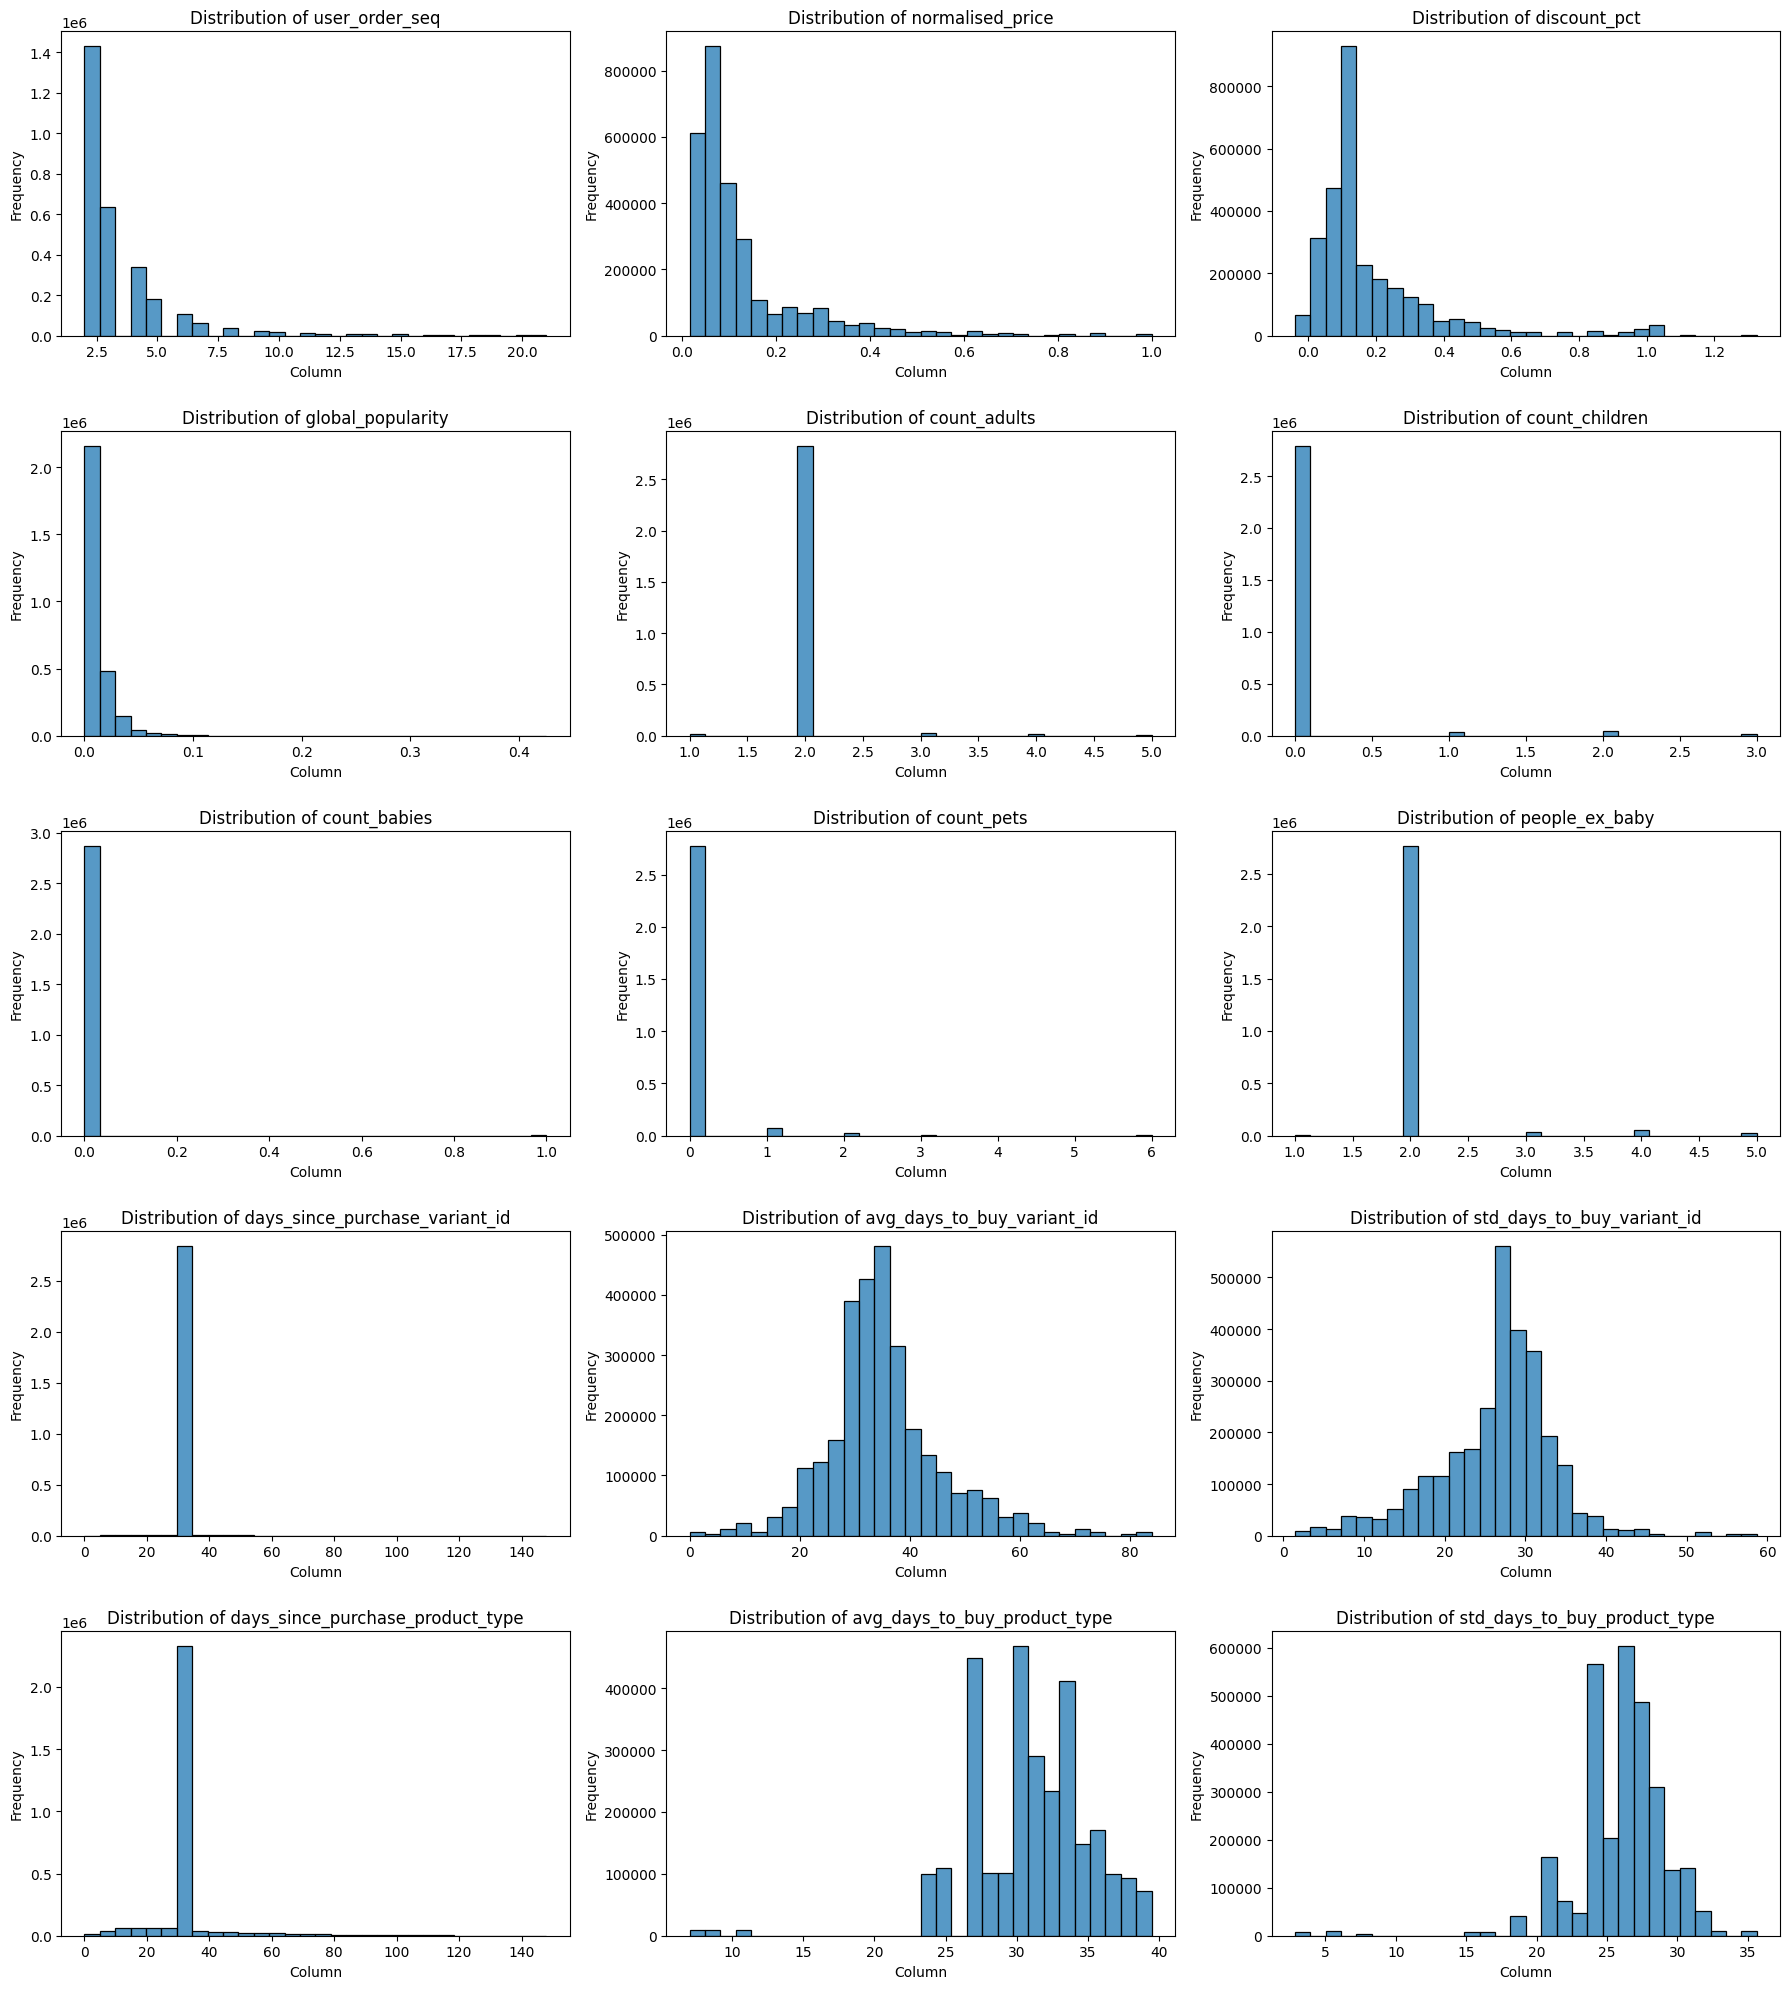

In [11]:
numerical_columns = df_orders[['user_order_seq', 'normalised_price', 'discount_pct', 'global_popularity', 'count_adults', 'count_children', 'count_babies', 'count_pets', 'people_ex_baby',
                                 'days_since_purchase_variant_id', 'avg_days_to_buy_variant_id', 'std_days_to_buy_variant_id', 'days_since_purchase_product_type', 'avg_days_to_buy_product_type', 'std_days_to_buy_product_type']]

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(18, 20))
axes = axes.flatten()

for i,column in enumerate(numerical_columns):
    sns.histplot(df_orders[column], bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {column}')
    axes[i].set_xlabel('Column')
    axes[i].set_ylabel('Frequency')
    
plt.tight_layout()
plt.show()

These charts are really valuable, since we infer some characteristics of the purchases. In the first graphs we see that the common user is the one that does little amount of purchases in this e-commerce (given that 'user_order_seq' is right-skewed) and that they tend to buy cheap products, although there are users with higher loyalty values, and expensive products too. Most of the customers are 2 adults per household without kids and pets, but there are also larger families. 
Days since last purchase (both of variant id and product type) is around 30 (one month after previous purchase) for many cases, which seems a bit weird unless there's maybe a special discount after one month from last purchase.
One thing that looks strange is that there are cases with discount_pct > 1, which would mean that the shop pays you, that makes no sense.

After reviewing all the distributions I consider that we only need to deal with the outliers of 'discount_pct', since I consider the other 'peaks' to be natural user behaviour (if this problem was real, I'd ask or look for data regarding the 30d re-purchase)

In [12]:
df_orders[df_orders['discount_pct'] > 1]['discount_pct'].value_counts()

discount_pct
1.013423    17230
1.010101     6892
1.001431     6892
1.006289     6892
1.020202     3446
1.325301     3446
1.010050     3446
1.006711     3446
1.003339     3446
1.132075     3446
Name: count, dtype: int64

In [13]:
# We will cap those values to 1, as it is not possible to have a discount higher than 100%
df_orders['discount_pct'] = df_orders['discount_pct'].apply(lambda x: 1 if x > 1 else x)

## Correlations between variables

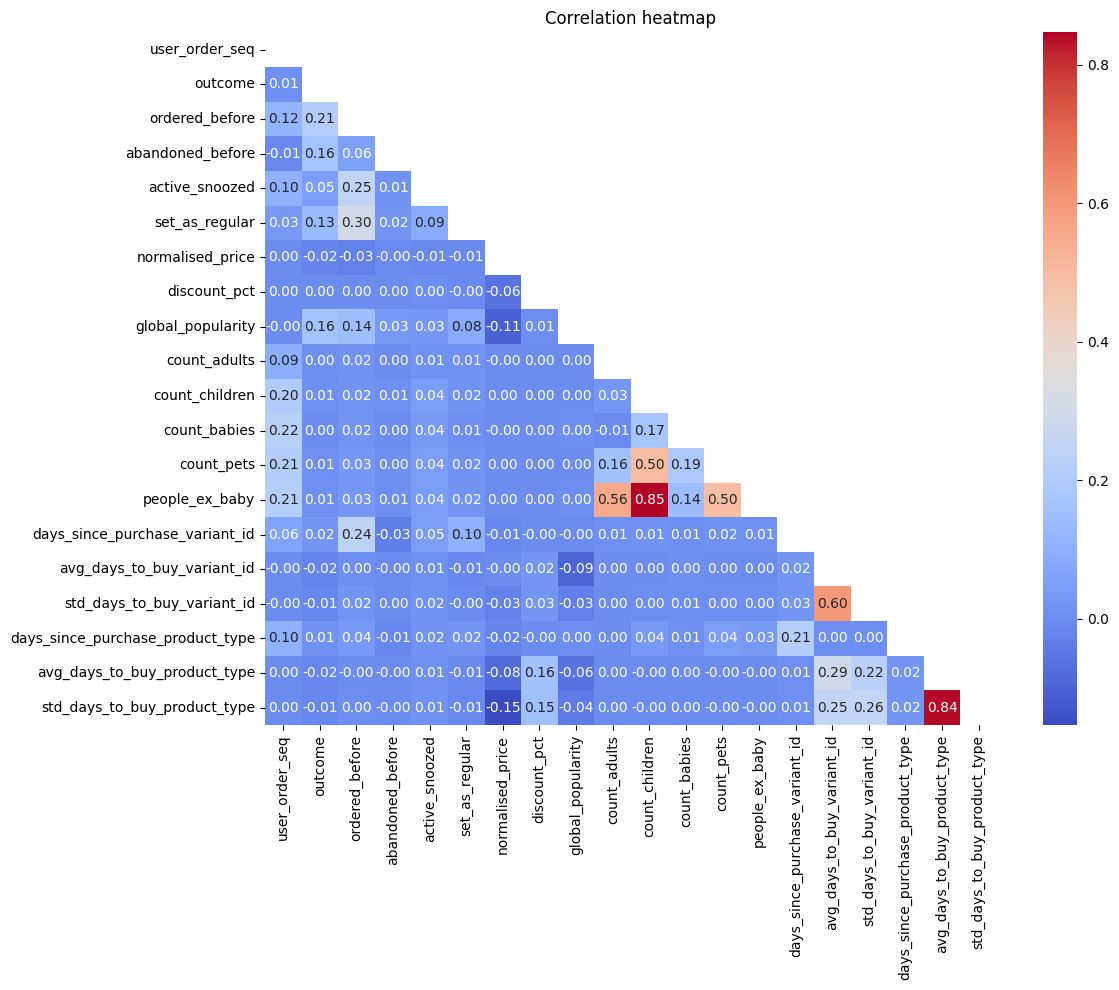

In [14]:
# Check the correlation between the numerical features with a heatmap
plt.figure(figsize=(12, 10))

id_columns = ['user_id', 'order_id', 'variant_id']
numerical_columns = df_orders.select_dtypes(include=['int64', 'float64'])
numerical_columns = numerical_columns.drop(columns=id_columns, errors='ignore')

corr_matrix = numerical_columns.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation heatmap')
plt.tight_layout()
plt.show()

We see a high correlation between 'people_ex_baby' and 'count_adults' and 'count_children', since people excluding babies is the sum of those variables, so 'people_ex_baby' should be deleted to avoid a multicollinearity problem. Then we also see a high correlation between 'avg_days_to_buy_variant_id' and 'std_days_to_buy_variant_id' which explains a pattern when users are buying: if they buy sth regularly (avg_days_to_buy_variant_id would be low) then the std_days_to_buy_variant_id is also low because there is little variation. Same logic for 'avg_days_to_buy_product_type' and 'std_days_to_buy_product_type'. For these variables I'm going to compute the VIF to see if there is a high multicollinearity. Values of VIF higher than 10 indicate a multicollinearity issue.

From the correlation matrix we also see that the variables that have more linear relation with 'outcome' (variable to predict) are 'ordered_before', 'days_since_purchase_product_type', 'active_snoozed', and the count_ variables.

In [15]:
# VIF for numerical predictors to check for multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = numerical_columns.drop(columns=['outcome'], errors='ignore')
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

/Users/mariajordamunoz/Library/Caches/pypoetry/virtualenvs/zrive-ds-Yy3t-uQX-py3.11/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                             feature         VIF
0                     user_order_seq    3.790808
1                     ordered_before    1.262233
2                   abandoned_before    1.005994
3                     active_snoozed    1.078707
4                     set_as_regular    1.106921
5                   normalised_price    2.057176
6                       discount_pct    2.011348
7                  global_popularity    1.465968
8                       count_adults         inf
9                     count_children         inf
10                      count_babies    1.085973
11                        count_pets    1.429117
12                    people_ex_baby         inf
13    days_since_purchase_variant_id   62.513203
14        avg_days_to_buy_variant_id   19.967011
15        std_days_to_buy_variant_id   23.348515
16  days_since_purchase_product_type    7.983033
17      avg_days_to_buy_product_type  183.343672
18      std_days_to_buy_product_type  214.366037


We see that the VIF is extremely high (inf) for count_adults, people_ex_baby and count_children, as people_ex_baby is explained by the other two. Additionally, days_since_purchase_variant_id, avg_days_to_buy_variant_id,std_days_to_buy_variant_id, avg_days_to_buy_product_type and std_days_to_buy_product_type also have VIF higher than 10, as days_since, avg and std are highly correlated. Keeping all variables could affect a predicting moddeling, so I'm going to drop the std variable (the avg variable is easier to understand)

In [16]:
df_orders.drop(columns=['people_ex_baby', 'std_days_to_buy_variant_id', 'std_days_to_buy_product_type'], inplace=True)

In [17]:
df_orders.dtypes

variant_id                                   int64
product_type                                object
order_id                                     int64
user_id                                      int64
created_at                          datetime64[ns]
order_date                          datetime64[ns]
user_order_seq                               int64
outcome                                      int64
ordered_before                               int64
abandoned_before                             int64
active_snoozed                               int64
set_as_regular                               int64
normalised_price                           float64
discount_pct                               float64
vendor                                      object
global_popularity                          float64
count_adults                                 int64
count_children                               int64
count_babies                                 int64
count_pets                     

## Categorical encoding

We have one variable that has str values: 'product_type'. If we want to use it with a model, we should transform its values to a numerical format

In [18]:
df_orders['product_type'].value_counts()

product_type
tinspackagedfoods         226474
condimentsdressings       129749
ricepastapulses           128098
haircare                  114978
cookingingredientsoils    110686
                           ...  
babyfood12months            6797
householdsundries           6735
petcare                     4075
feedingweaning              2790
premixedcocktails           2620
Name: count, Length: 62, dtype: int64

In [19]:
df_orders['product_type'].unique()

array(['ricepastapulses', 'snacksconfectionery', 'dishwasherdetergent',
       'cleaningaccessories', 'fabricconditionerfreshener', 'coffee',
       'femininecare', 'bathroomlimescalecleaner', 'handsoapsanitisers',
       'tinspackagedfoods', 'toiletroll', 'kitchenrolltissues', 'binbags',
       'windowglasscleaner', 'homebaking', 'tea', 'jamhoneyspreads',
       'washingliquidgel', 'longlifemilksubstitutes', 'allpurposecleaner',
       'softdrinksmixers', 'condimentsdressings', 'babyfood6months',
       'kidssnacks', 'cookingingredientsoils', 'floorcleanerpolish',
       'cereal', 'driedfruitsnutsseeds', 'pickledfoodolives', 'catfood',
       'cookingsaucesmarinades', 'juicesquash', 'beer', 'kidsdental',
       'nappies', 'maternity', 'washingpowder', 'dental', 'haircare',
       'bathshowergel', 'kitchenovencleaner', 'wipescottonwool',
       'dogfood', 'babytoiletries', 'foodstorage', 'shavinggrooming',
       'petcare', 'deodorant', 'washingcapsules', 'bodyskincare',
       'delica

We have many different types of product, so we cannot use one hot encoding, because that would create many many variables. Ordinal or label encoding would create an order that does not exist in the variable.
Using target encoding, a method that transforms categorical variables into numerical values based on the target variable, is more suitable in this scenario. Based on the documentation of the [TargetEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.TargetEncoder.html) class, each category is encoded based on a shrunk estimate of the avg target values for observations belonging to the category. 

An important observation is that in order to mitigate overfitting, target encoding blends the global target mean (the prior, in Bayes terms) with the category-specific target mean (the posterior) using a regularization mechanism. This is achieved by using a smoothing parameter that ensures rare categories are not overly represented, thus reducing the risk of overfitting and improving the stability of the encoded values.

In [23]:
# We use target encoding (from sklearn) for the product_type column, as it has a high cardinality and it is not ordinal
from sklearn.preprocessing import TargetEncoder

encoder = TargetEncoder(categories='auto', target_type='continuous', smooth='auto', cv=5, random_state=42)
df_orders['product_type_encoded'] = encoder.fit_transform(df_orders[['product_type']], df_orders['outcome'])

df_orders[['product_type', 'product_type_encoded', 'outcome']].sample(10)

,product_type,product_type_encoded,outcome
584013,ricepastapulses,0.011760,0
273413,homebaking,0.019956,0
2681399,nappypants,0.001058,0
469748,washingpowder,0.006140,0
1861771,pickledfoodolives,0.011238,0
1027895,driedfruitsnutsseeds,0.015605,0
1244983,tinspackagedfoods,0.019468,0
2401234,wipescottonwool,0.008705,0
571359,tea,0.012398,0
1696236,tinspackagedfoods,0.019561,0


If new values are inserted in 'product_type', this method does not fail, it applies the fallback: setting the avg probability of the entire catalog, since the new value would not have purchasing history, so the method is robust. If many new values are frequently created, we should consider retraining the TargetEncoding with some frequency (e.g., bimonthly)

### EDA completed.